In [2]:
# print all the outputs in a cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Research Question: How do socioeconomic indicators and demographic factors influence suicide rates?

#### Hypothesis 1: Demographic factors such as gender and age don't play a big role in determining suicide rates.
#### Hypothesis 2: Lower GDP per capita will increase suicide rates.
#### Hypothesis 3: Global crises will negatively impact suicide rates, we will look at the 2008 global financial crisis.

#### The Dataset: https://www.kaggle.com/code/kralmachine/data-visualization-of-suicide-rates/input
#### The dataset was from kaggle and inlcudes the following features:
- country -> What country the data was from, 101 countries being explored in the dataset
- year -> What year the suicide rates are from, the dataset contains data from 1987-2016
- sex -> Gender of the person
- age -> What age group the person was in
- suicides_no -> Number of suicides
- population -> Total population
- suicides_100k pop -> Suicided per 100k of the population
- country-year -> Combination of country and year
- HDI for year -> Human Development Index of that year
- gdp_for_year -> GDP for the year
- gdp_per_capita -> GDP per capita for the year
- generation -> Generation of the person

#### Data Exploration

In [7]:
df = pd.read_csv('master.csv')

In [9]:
df.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [11]:
df.shape

(27820, 12)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


#### Data Preparation

1) Rename the columns to make it easier to read
2) Drop columns that don't provide any useful insight or are not relevant to our research question
3) Check for missing values


In [15]:
df.rename(columns=lambda x: x.strip().lower().replace(' ', '_'), inplace=True) 
df.rename(columns={'suicides/100k_pop': 'suicides_100k_pop'}, inplace=True)
df.drop(columns='hdi_for_year', inplace=True) 
df.drop(columns='country-year', inplace=True) 
#no more missing values
df.isnull().sum()


country               0
year                  0
sex                   0
age                   0
suicides_no           0
population            0
suicides_100k_pop     0
gdp_for_year_($)      0
gdp_per_capita_($)    0
generation            0
dtype: int64

#### Exploring the new cleaned data

In [17]:
df.shape

(27820, 10)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides_100k_pop   27820 non-null  float64
 7   gdp_for_year_($)    27820 non-null  object 
 8   gdp_per_capita_($)  27820 non-null  int64  
 9   generation          27820 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 2.1+ MB


In [21]:
df.head() 

,country,year,sex,age,suicides_no,population,suicides_100k_pop,gdp_for_year_($),gdp_per_capita_($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,"2,156,624,900",796,Boomers


### Finding 1
We thought that demograohic factors such as age and gender would not play a big role in affecting suicide rates;
however, we found out that they do in fact inpact suicide rates significantly. Not only is it apparent from the graphs that males have a much higher suicide rate than females but it is also worth noting that the older population has an alarmingly high suicide rate. 
### Testing Hypothesis 1

In [23]:
#Gender-based aggregation
df.groupby('sex').size() #same amout of males and females
gender_stats = df.groupby('sex')['suicides_100k_pop'].mean()
gender_stats

sex
female    13910
male      13910
dtype: int64

sex
female     5.392866
male      20.239329
Name: suicides_100k_pop, dtype: float64

<Axes: title={'center': 'Average Suicide Rate by Gender'}, xlabel='sex'>

Text(0.5, 0, 'Gender')

Text(0, 0.5, 'Suicides per 100k')

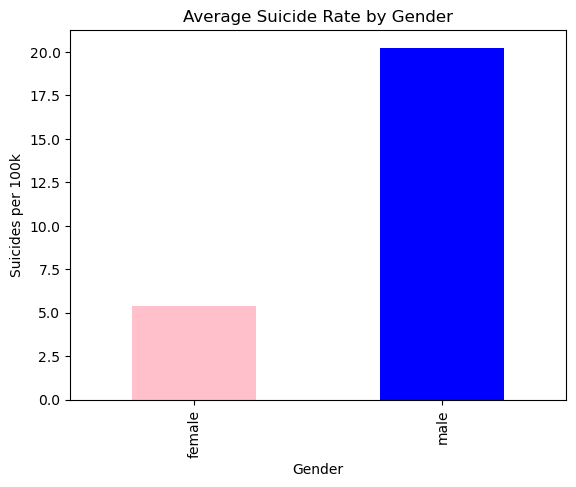

In [25]:
#Plotting the data
gender_stats.plot(kind='bar', color=['pink', 'blue'], title='Average Suicide Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Suicides per 100k')
plt.show()

We can see that the males have a much larger suicide rate with 20.2 suicides per 100k people whereas 
females are at 5.4 suicides per 100k people

In [27]:
#Age group aggregation
age_group_stats = df.groupby('age')['suicides_100k_pop'].mean()
age_group_stats

age
15-24 years     8.947154
25-34 years    12.186885
35-54 years    14.947441
5-14 years      0.620041
55-74 years    16.155579
75+ years      23.955409
Name: suicides_100k_pop, dtype: float64

<Axes: title={'center': 'Average Suicide Rate by Age Group'}, xlabel='age'>

Text(0.5, 0, 'Age Group')

Text(0, 0.5, 'Suicides per 100k')

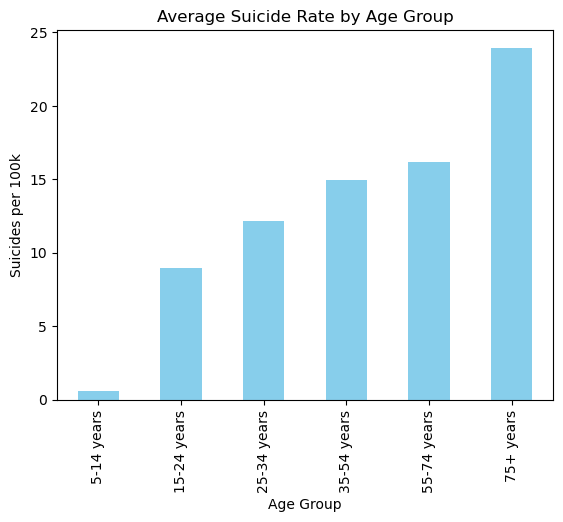

In [29]:
#Plotting the data
age_order=['5-14 years', '15-24 years', '25-34 years', '35-54 years', '55-74 years' , '75+ years']
# Reindex the Series based on the desired order
age_group_stats = age_group_stats.reindex(age_order)

#Plot
age_group_stats.plot(kind='bar', color='skyblue', title='Average Suicide Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Suicides per 100k') 
plt.show()

This shows that the highest suicide rate occurs with people over the age of 75. This is a bit of a surprise and not necessarily what we expected to see.

In [31]:
#Group by gender and age
combined_stats = df.groupby(['sex', 'age'])['suicides_100k_pop'].mean().unstack()
combined_stats = combined_stats[age_order]
combined_stats

age,5-14 years,15-24 years,25-34 years,35-54 years,55-74 years,75+ years
sex,,,,,,
female,0.462252,4.328018,4.57321,5.916480,7.123447,9.919802
male,0.777831,13.566290,19.80056,23.978402,25.187712,37.991017


/Users/alvaromuller-baumgart/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Text(0.5, 1.0, 'Suicide Rates by Age Group and Gender')

Text(35.91007330246914, 0.5, 'Suicides per 100k')

Text(0.5, 29.00000000000003, 'Age Group')

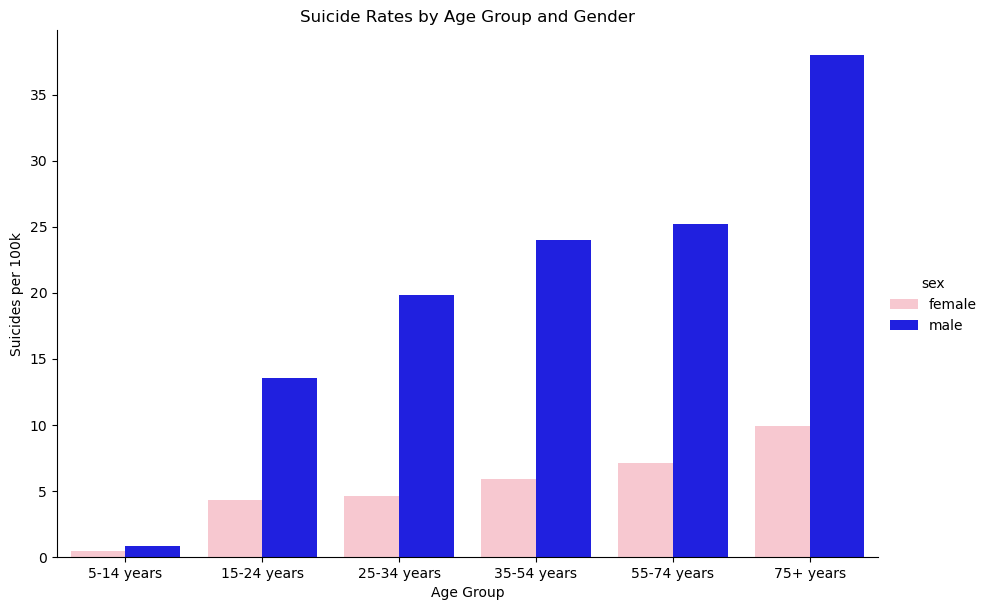

In [33]:
#Visualization
#Since we unstacked we created a pivoted df which is not suitable for catplot
#Reset the index and melt the combined_stats DataFrame for long-format data
long_format = combined_stats.reset_index().melt(id_vars='sex', var_name='age', value_name='suicides_100k_pop')

sns.catplot(x='age', y='suicides_100k_pop', hue='sex', data=long_format, kind='bar', height=6, aspect=1.5, palette={'female': 'pink', 'male': 'blue'})
plt.title('Suicide Rates by Age Group and Gender')
plt.ylabel('Suicides per 100k')
plt.xlabel('Age Group')
plt.show()

gen_group_stats = df.groupby('generation')['suicides_100k_pop'].mean()
gen_group_stats

#Plotting the data
gen_order=['Generation Z', 'Millenials', 'Generation X', 'Boomers', 'Silent' , 'G.I. Generation']
#Reindex the Series based on the desired order
gen_group_stats = gen_group_stats.reindex(gen_order)

#Plot
gen_group_stats.plot(kind='bar', color='skyblue', title='Average Suicide Rate by Generation')
plt.title('Average Suicide Rates by Generation')
plt.xlabel('Generation')
plt.ylabel('Suicides per 100k')
plt.show()

#### Manegerial Insight
After these findings we came up with some solutions that may potentially help balance out suicide rates amongst demographics. Firstly, we believe it is extremely important to raise awareness of male mental health. It is a topic not talked about enough and one neglected due to the notion of males seeking help being deemed weak. By launching a campaign about male mental health it should be possible to redirect this idea, hopefully leading to more men seeking professional help. 

After finding out that demogrpahics influence suicide rates significantly, we wanted to explore if this held true throughout different countries. To do so we randomly selected 5 countries in our dataset and plotted the suicide rate versus age.  

/Users/alvaromuller-baumgart/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Text(0.5, 9.444444444444438, 'Country')

Text(2007.8027777777775, 0.5, 'Suicides per 100k')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '5-14 years'),
  Text(1, 0, '15-24 years'),
  Text(2, 0, '25-34 years'),
  Text(3, 0, '35-54 years'),
  Text(4, 0, '55-74 years'),
  Text(5, 0, '75+ years')])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/var/folders/2c/1f07cltj5jbc1kt6pjwl3w7h0000gn/T/ipykernel_1982/3369962108.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


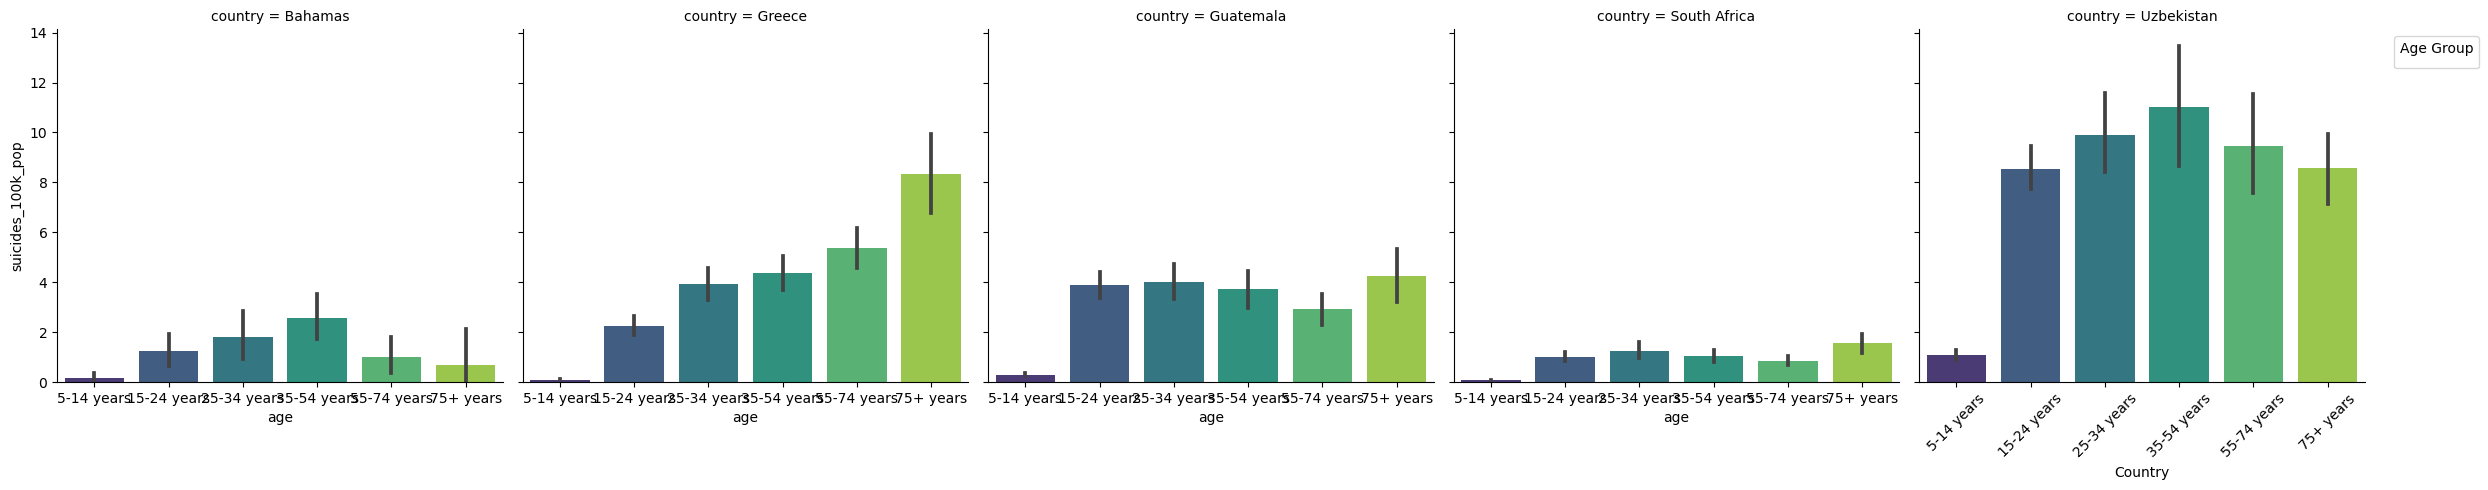

In [35]:
#Filter countries that appear more than 200 times
filtered_countries = df[df['country'].isin(df['country'].value_counts()[df['country'].value_counts() > 200].index)]
#Sample 5 countries from the filtered DataFrame
sampled_countries = filtered_countries['country'].sample(n=5, random_state=42)
#Filter the original DataFrame to include only the sampled countries
df_sampled = df[df['country'].isin(sampled_countries)]

sns.catplot(
    data=df_sampled,
    x='age',
    y='suicides_100k_pop',
    order=age_order, 
    col='country',
    palette='viridis',
    kind='bar'
)


plt.xlabel('Country')
plt.ylabel('Suicides per 100k')
plt.xticks(rotation=45)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Here we can see that even though suicide rate is typically the highest for the 75+ years age group it isn't the case for every country. Hence, we want to find what variables play the biggest role in suicide rates and use that to investigate why in countries like the bahamas the suicide rate is the highest for 35-54 year olds. To find what other variables influence suicide rates we will build a model. 

### Building a model to see which variables are the most important in determining suicide rates

In [37]:
df = pd.get_dummies(df, columns=['sex', 'age', 'generation', 'country'], drop_first=True)
df.head()

,year,suicides_no,population,suicides_100k_pop,gdp_for_year_($),gdp_per_capita_($),sex_male,age_25-34 years,age_35-54 years,age_5-14 years,...,country_Thailand,country_Trinidad and Tobago,country_Turkey,country_Turkmenistan,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Uruguay,country_Uzbekistan
0,1987,21,312900,6.71,"2,156,624,900",796,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1987,16,308000,5.19,"2,156,624,900",796,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,1987,14,289700,4.83,"2,156,624,900",796,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1987,1,21800,4.59,"2,156,624,900",796,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1987,9,274300,3.28,"2,156,624,900",796,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [39]:
#I was getting an error with the model in the line below saying that the dataframe is being cast to object type hence I wanted
#to check where that was coming from
df = df.apply(pd.to_numeric, errors='coerce')#Convert all columns to numeric, coercing errors to NaN
df.info()
df[df.select_dtypes(include=[bool]).columns] = df.select_dtypes(include=[bool]).astype(int)
np.asarray(df).dtype
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Columns: 117 entries, year to country_Uzbekistan
dtypes: bool(111), float64(2), int64(4)
memory usage: 4.2 MB


dtype('float64')

,year,suicides_no,population,suicides_100k_pop,gdp_for_year_($),gdp_per_capita_($),sex_male,age_25-34 years,age_35-54 years,age_5-14 years,...,country_Thailand,country_Trinidad and Tobago,country_Turkey,country_Turkmenistan,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States,country_Uruguay,country_Uzbekistan
0,1987,21,312900,6.71,NaN,796,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1987,16,308000,5.19,NaN,796,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1987,14,289700,4.83,NaN,796,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1987,1,21800,4.59,NaN,796,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1987,9,274300,3.28,NaN,796,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
import statsmodels.api as sm

# Dependent variable (Y)
y = df['suicides_100k_pop']
# Independent variables (X) including relevant predictors and control variables
X = df[['gdp_per_capita_($)', 'population'] + 
       [col for col in df.columns if 'sex_' in col or 'age_' in col or 'generation_' in col or 'country_' in col]]
X = sm.add_constant(X)


In [43]:
model = sm.OLS(y, X)  # Ordinary Least Squares (OLS) regression
results = model.fit()

In [45]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      suicides_100k_pop   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     265.2
Date:                Wed, 04 Dec 2024   Prob (F-statistic):               0.00
Time:                        20:04:02   Log-Likelihood:            -1.1113e+05
No. Observations:               27820   AIC:                         2.225e+05
Df Residuals:                   27706   BIC:                         2.234e+05
Df Model:                         113                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -6.8711      0.906     -7.580      0.000      -8.648      -5.094
gdp_per_capita_($)                      -0.0001   9.92e-06    -10.891      0.000      -0.000   -8.86e-05
population                             1.23e-07   4.71e-08      2.614      0.009    3.08e-08    2.15e-07
sex_male                                14.8573      0.158     94.057      0.000      14.548      15.167
age_25-34 years                          2.9275      0.307      9.545      0.000       2.326       3.529
age_35-54 years                          5.2013      0.429     12.138      0.000       4.361       6.041
age_5-14 years                          -8.5908      0.320    -26.849      0.000      -9.218      -7.964
age_55-74 years                          6.2638      0.585     10.704      0.000       5.117       7.411
age_75+ years                           13.4835      0.654     20.611      0.000      12.201      14.766
generation_G.I. Generation               2.2303      0.528      4.227      0.000       1.196       3.264
generation_Generation X                 -0.4922      0.343     -1.434      0.152      -1.165       0.181
generation_Generation Z                  0.3786      0.644      0.588      0.556      -0.883       1.640
generation_Millenials                   -1.0188      0.454     -2.244      0.025      -1.909      -0.129
generation_Silent                       -0.2046      0.396     -0.517      0.605      -0.981       0.571
country_Antigua and Barbuda             -2.0291      1.095     -1.853      0.064      -4.175       0.117
country_Argentina                        7.2870      1.068      6.825      0.000       5.194       9.380
country_Armenia                         -0.2202      1.114     -0.198      0.843      -2.403       1.963
country_Aruba                            8.6650      1.315      6.591      0.000       6.088      11.242
country_Australia                       12.6414      1.110     11.388      0.000      10.466      14.817
country_Austria                         23.6400      1.100     21.500      0.000      21.485      25.795
country_Azerbaijan                      -1.7977      1.249     -1.439      0.150      -4.246       0.651
country_Bahamas                          0.4368      1.155      0.378      0.705      -1.828       2.702
country_Bahrain                          0.2131      1.169      0.182      0.855      -2.077       2.503
country_Barbados                         0.5845      1.116      0.524      0.600      -1.603       2.772
country_Belarus                         27.7037      1.160     23.878      0.000      25.430      29.978
country_Belgium                         20.9086      1.100     19.012      0.000      18.753      23.064
country_Belize                        

#### Model summary
By looking at the model summary, specifically the coef column we can see what variables impact the suicide rate the most. The model mostly comfirms what we already saw from the graphs above. Even though, the model indicates no significant correlation between suicide rates and GDP, it was still something we wanted to explore as it was a variable we thought would play a big role. To start this exploration we looked at the countries with the highest coef values and sorted them. We then looked at that countries GDP per capita.  We will go into further detail about GDP in hypothesis 2.

In [47]:
#Extract and sort country-related coefficients (assuming they are named like 'country_countryname')
country_coefficients = results.params.filter(like='country_').sort_values(ascending=False)
#Get the top 5 countries
top_5_countries = country_coefficients.head(5)
print(top_5_countries)


country_Lithuania             37.820079
country_Sri Lanka             31.528326
country_Russian Federation    30.592632
country_Hungary               30.063958
country_Belarus               27.703718
dtype: float64


In [49]:
#Extract the top 5 country dummy variable names
top_5_country_dummies = top_5_countries.index
top_5_country_names = top_5_country_dummies.str.replace('country_', '')

In [51]:
#Add a 'country' column to the DataFrame
df['country'] = df[top_5_country_dummies].idxmax(axis=1).str.replace('country_', '')
#Step 3: Filter for the top 5 countries
top_5_df = df[df['country'].isin(top_5_country_names)]
#Calculate the average GDP per capita for each country
avg_gdp_per_capita = top_5_df.groupby('country')['gdp_per_capita_($)'].mean()

# Display the results
print("Average GDP per capita for the top 5 countries:")
print(avg_gdp_per_capita)


Average GDP per capita for the top 5 countries:
country
Belarus                3333.904762
Hungary                9370.051613
Lithuania             17284.110141
Russian Federation     6518.814815
Sri Lanka               904.272727
Name: gdp_per_capita_($), dtype: float64


/var/folders/2c/1f07cltj5jbc1kt6pjwl3w7h0000gn/T/ipykernel_1982/3014528625.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['country'] = df[top_5_country_dummies].idxmax(axis=1).str.replace('country_', '')


From an initial analysis it seems the model is correct in saying that GDP per capita doesn't affect suicide rates that much as Lithuania, the country with the highest coef had a higher GDP than other countries. 

#### Model Performance
Plotting grpah of residuals and graph of actual vs predicted

(array([1.500e+01, 1.550e+02, 8.480e+02, 2.856e+03, 8.086e+03, 9.223e+03,
        3.945e+03, 1.505e+03, 3.710e+02, 2.320e+02, 2.010e+02, 1.390e+02,
        8.400e+01, 5.100e+01, 3.500e+01, 2.500e+01, 1.400e+01, 7.000e+00,
        5.000e+00, 7.000e+00, 2.000e+00, 5.000e+00, 4.000e+00, 2.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00]),
 array([-42.35023866, -34.45372831, -26.55721796, -18.66070761,
        -10.76419726,  -2.86768691,   5.02882344,  12.92533379,
         20.82184413,  28.71835448,  36.61486483,  44.51137518,
         52.40788553,  60.30439588,  68.20090623,  76.09741658,
         83.99392693,  91.89043728,  99.78694762, 107.68345797,
        115.57996832, 123.47647867, 131.37298902, 139.26949937,
        147.16600972, 155.06252007, 162.95903042, 170.85554077,
        178.75205111, 186.64856146, 194.54507181]),
 <BarContainer object of 30 artists>)

Text(0.5, 1.0, 'Histogram of Residuals')

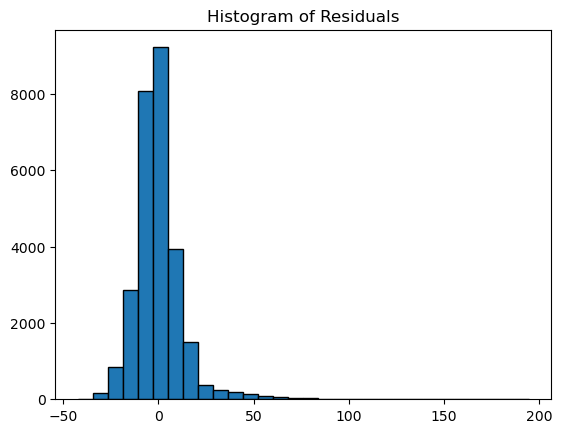

In [53]:
residuals = results.resid
plt.hist(residuals, bins=30, edgecolor='k')
plt.title('Histogram of Residuals')
plt.show()

Text(0.5, 0, 'Actual Suicide Rates')

Text(0, 0.5, 'Predicted Suicide Rates')

Text(0.5, 1.0, 'Actual vs. Predicted')

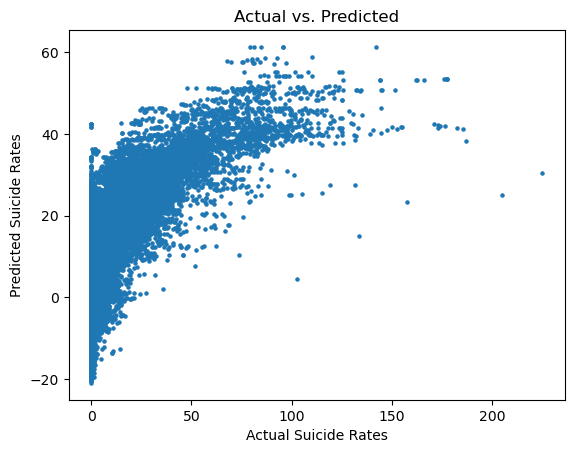

In [55]:
predictions = results.predict(X)
plt.scatter(y, predictions, s=5)
plt.xlabel('Actual Suicide Rates')
plt.ylabel('Predicted Suicide Rates')
plt.title('Actual vs. Predicted')
plt.show()

#### Model performance
By looking at the residual plot we can see the model was a good fit for our data.
We can see it is normally distributed and clustered around 0 indicating the model’s errors are symmetrically distributed and consistent, which is ideal.
The actual vs predicted also shows that our model did a decent job at predicting suicide rates but it was far from perfect. Hence we will be looking at how GDP affects suicide rates in order to check our second hypothesis more clearly.

Alvaro did until this point. (i.e. hypothesis 1 and statsmodel)

### Finding 2
As we predicted, Suicide rates tend to decrease as GDP per capita increases, indicating an inverse relationship. Countries with a lower gdp per capita had higher suicide rates, clearly illustrated in the graphs above. We also explored how a steadily increasing gdp per capita in a country can have a positive impact in reducing suicide rates as the people feel a greater sense of stability. 
### Testing Hypothesis 2

In [57]:
# Clean and prepare data
df = df.rename(columns={' gdp_for_year_($) ': 'gdp_for_year'})

# Creating a GDP category column (Low, Medium, High based on quartiles)
gdp_quartiles = pd.qcut(df['gdp_per_capita_($)'], q=3, labels=['Low', 'Medium', 'High'])
df['GDP Category'] = gdp_quartiles

# Log-transforming GDP for better scaling
df['log_gdp_per_capita'] = np.log(df['gdp_per_capita_($)'] + 1)

<Axes: xlabel='gdp_per_capita_($)', ylabel='suicides_100k_pop'>

Text(0.5, 1.0, 'GDP per Capita vs. Suicide Rates')

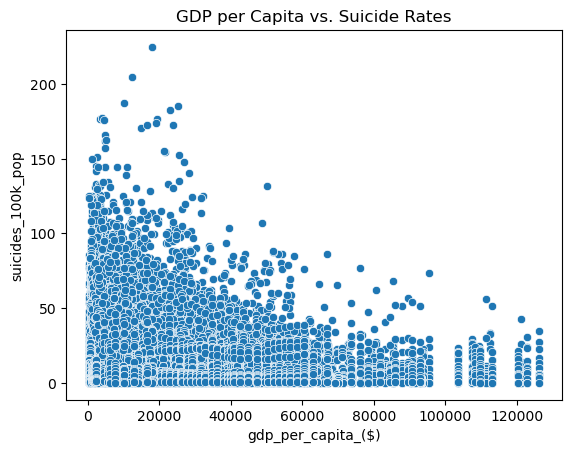

,gdp_per_capita_($),suicides_100k_pop
gdp_per_capita_($),1.000000,0.001785
suicides_100k_pop,0.001785,1.000000


In [59]:
# Correlation analysis
correlation = df[['gdp_per_capita_($)', 'suicides_100k_pop']].corr()
sns.scatterplot(x='gdp_per_capita_($)', y='suicides_100k_pop', data=df)
plt.title('GDP per Capita vs. Suicide Rates')
plt.show()
correlation

Text(0.5, 1.0, 'Trends in Japan: Suicide Rates vs. GDP')

Text(0.5, 0, 'Year')

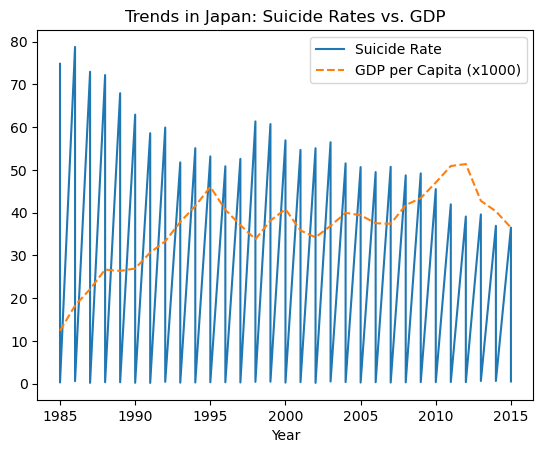

In [61]:
data = pd.read_csv('master.csv')

#Example country analysis: Japan
country_data = data[data['country'] == 'Japan']
plt.plot(country_data['year'], country_data['suicides/100k pop'], label='Suicide Rate')
plt.plot(country_data['year'], country_data['gdp_per_capita ($)'] / 1000, label='GDP per Capita (x1000)', linestyle='--')
plt.legend()
plt.title('Trends in Japan: Suicide Rates vs. GDP')
plt.xlabel('Year')
plt.show()

<Axes: xlabel='GDP Category', ylabel='suicides_100k_pop'>

Text(0.5, 1.0, 'Suicide Rates by GDP Category')

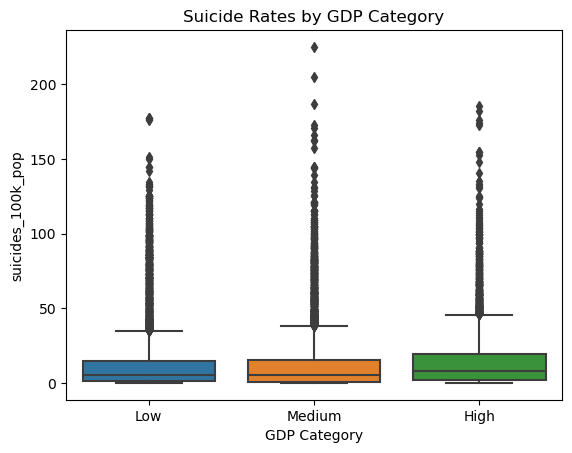

In [63]:
#Boxplot analysis
sns.boxplot(x='GDP Category', y='suicides_100k_pop', data=df)
plt.title('Suicide Rates by GDP Category')
plt.show()

**Managerial Insight**: Investing in economic development programs and targeted mental health support , especially in low-GDP regions, could have a positive impact on reducing suicide rates. Moreover, monitoring GDP trends alongside mental health indicators can help governments identify at-risk populations and allocate resources effectively.

Manish did this part (i.e. Hypothesis 2)

### Finding 3
We saw that even though there was a global crisis, suicide rates actually went down. This is completely opposite to what we originally thought as we thought that a global crisis would increase suicide rates due to it creating more problems for people. 

### Testing Hypothesis 3

In [65]:
#Filter data for 2006-2010
filtered_data = data[(data['year'] >= 2006) & (data['year'] <= 2010)]

#Create a column for the crisis period
filtered_data['crisis_period'] = filtered_data['year'].apply(
    lambda x: 'Pre-Crisis (2006-2008)' if x <= 2008 else 'Post-Crisis (2009-2011)'
)

filtered_data.groupby('crisis_period').agg({
    'suicides/100k pop': 'mean'
}).reset_index()

/var/folders/2c/1f07cltj5jbc1kt6pjwl3w7h0000gn/T/ipykernel_1982/2822516174.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['crisis_period'] = filtered_data['year'].apply(


,crisis_period,suicides/100k pop
0,Post-Crisis (2009-2011),11.308865
1,Pre-Crisis (2006-2008),11.953776


Here we can actually see that the average suicide rate goes down post crisis. Contrary to our hypothesis

In [69]:
#Aggregate suicide rates by crisis period
gender_analysis = filtered_data.groupby(['crisis_period', 'sex']).agg({
    'suicides/100k pop': 'mean'
}).reset_index()

age_analysis = filtered_data.groupby(['crisis_period', 'age']).agg({
    'suicides/100k pop': 'mean'
}).reset_index()

<Axes: xlabel='crisis_period', ylabel='suicides/100k pop'>

Text(0.5, 1.0, 'Suicide Rates by Gender: Pre- and Post-Crisis')

Text(0, 0.5, 'Suicides per 100k Population')

Text(0.5, 0, 'Crisis Period')

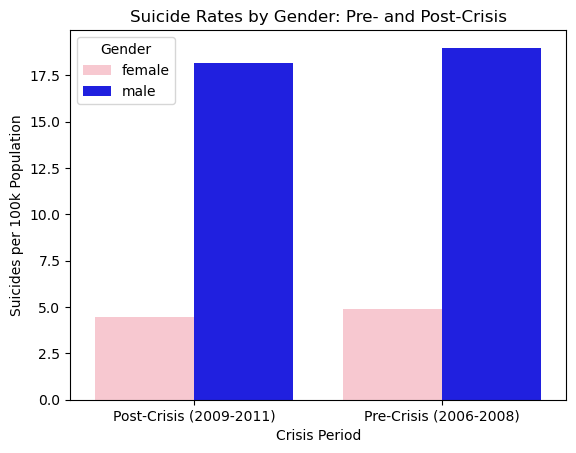

In [71]:
sns.barplot(x='crisis_period', y='suicides/100k pop', hue='sex', palette={'female': 'pink', 'male': 'blue'}, data=gender_analysis)
plt.title('Suicide Rates by Gender: Pre- and Post-Crisis')
plt.ylabel('Suicides per 100k Population')
plt.xlabel('Crisis Period')
plt.legend(title='Gender')
plt.show()

<Axes: xlabel='age', ylabel='suicides/100k pop'>

Text(0.5, 1.0, 'Suicide Rates by Age Group: Pre- and Post-Crisis')

Text(0, 0.5, 'Suicides per 100k Population')

Text(0.5, 0, 'Age Group')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '5-14 years'),
  Text(1, 0, '15-24 years'),
  Text(2, 0, '25-34 years'),
  Text(3, 0, '35-54 years'),
  Text(4, 0, '55-74 years'),
  Text(5, 0, '75+ years')])

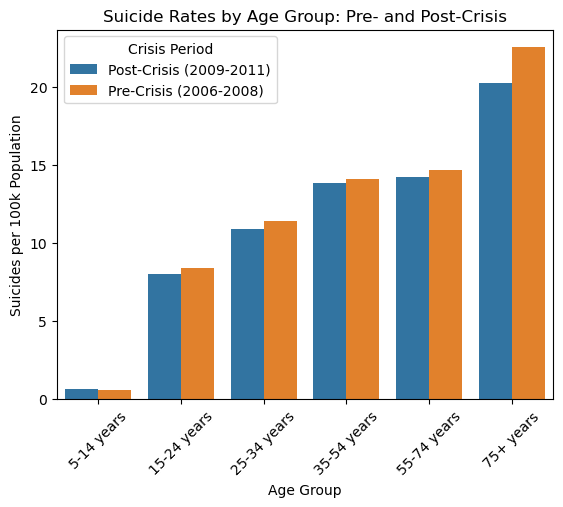

In [73]:
age_order = ['5-14 years', '15-24 years', '25-34 years', '35-54 years', '55-74 years', '75+ years']
sns.barplot(x='age', y='suicides/100k pop', hue='crisis_period', data=age_analysis, order = age_order)
plt.title('Suicide Rates by Age Group: Pre- and Post-Crisis')
plt.ylabel('Suicides per 100k Population')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.legend(title='Crisis Period')
plt.show()

**Summary**: Suicide rates decreased from 18.99/100k (pre-crisis) to 18.15/100k (post-crisis) for males, and suicide rates decreased from 4.91/100k (pre-crisis) to 4.47/100k (post-crisis). The age group of 75+ years had the largest decline from 22.54/100k (pre-crisis) to 20.24/100k (post-crisis). 


In [98]:
filtered_data['post_crisis'] = filtered_data['crisis_period'].apply(
    lambda x: 1 if 'Post-Crisis' in x else 0
)
filtered_data = filtered_data.dropna(subset=['post_crisis', 'suicides/100k pop'])

filtered_data[['suicides/100k pop', 'post_crisis']].corr()


/var/folders/2c/1f07cltj5jbc1kt6pjwl3w7h0000gn/T/ipykernel_339/1518498592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['post_crisis'] = filtered_data['crisis_period'].apply(


,suicides/100k pop,post_crisis
suicides/100k pop,1.000000,-0.018031
post_crisis,-0.018031,1.000000


Here we can see that there is a slight negative correlation between post crisis and suicide rates, meaning that the suicide rate goes down post crisis.

<Figure size 600x300 with 0 Axes>

<Axes: xlabel='year', ylabel='suicides/100k pop'>

Text(0.5, 1.0, 'Suicide Rates throughout crisis')

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Suicides per 100k Population')

([<matplotlib.axis.XTick at 0x157ed5910>,
 [Text(2006, 0, '2006'),
  Text(2007, 0, '2007'),
  Text(2008, 0, '2008'),
  Text(2009, 0, '2009'),
  Text(2010, 0, '2010')])

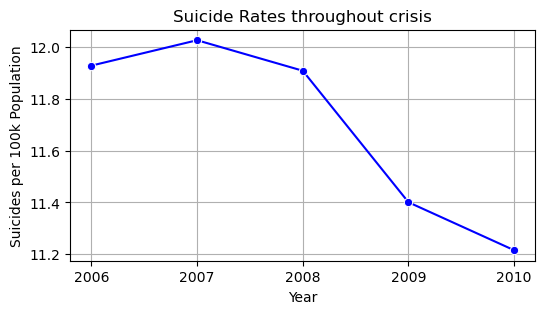

In [76]:
yearly_analysis = filtered_data.groupby(['year', 'crisis_period']).agg({
    'suicides/100k pop': 'mean'
}).reset_index()

# Filter data for pre-crisis and post-crisis
pre_crisis_data = yearly_analysis[yearly_analysis['crisis_period'] == 'Pre-Crisis (2006-2008)']
post_crisis_data = yearly_analysis[yearly_analysis['crisis_period'] == 'Post-Crisis (2009-2011)']
plt.figure(figsize=(6, 3))  # Adjust the figure size (width, height)

# Plot pre-crisis data
sns.lineplot(x='year', y='suicides/100k pop', data=yearly_analysis, marker='o', color='blue')
plt.title('Suicide Rates throughout crisis')
plt.xlabel('Year')
plt.ylabel('Suicides per 100k Population')
plt.xticks(ticks=[2006, 2007, 2008, 2009, 2010], labels=['2006', '2007', '2008', '2009','2010'])  # Set x-axis ticks
plt.grid(True)
plt.show()



**Summary**: Suicide rates decreased from 11.95/100k (pre-crisis) to 11.3/100k (post-crisis). The trends were different, as before the crisis there was a steady increase followed by a steady decline, whereas after the crisis there was an immediate decline. 


**Managerial Insight**:  The decline in suicide rates after the crisis may be attributed to an increase in mental health awareness, economic stimulus measures, and government policy interventions. Males may also be more at risk for suicide due to societal pressures and and fewer support networks. 

Sanjay did finding 3
